# 02 · CNN baseline desde cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EstebanGuerrero125/steel-defect-detection-cnn/blob/main/notebooks/02_cnn_baseline.ipynb)

**Objetivo:** entrenar una CNN pequeña desde cero como *baseline*. Su resultado es la referencia contra la que se comparará MobileNetV2 con transfer learning en el paso 3.

> En Colab activa la GPU: *Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)*.

Decisiones tomadas a partir de la exploración (notebook 01):

| Hallazgo en el paso 1 | Decisión |
|---|---|
| El dataset solo trae `train` (1.440) y `validation` (360) | `validation` se reserva como **test** y solo se usa al final. De `train` se separa un 15 % estratificado para validar durante el entrenamiento. |
| `patches_101.jpg` y `patches_105.jpg` son idénticas | Se eliminan duplicados antes de dividir. |
| Imágenes de 200×200 guardadas en RGB, pero en escala de grises | Se cargan con **1 canal** a 200×200. |
| El brillo medio cambia mucho entre clases | **Aumento de datos** con cambios de brillo y contraste para que el modelo aprenda la forma del defecto y no la iluminación. |

## 1. Configuración

In [1]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/EstebanGuerrero125/steel-defect-detection-cnn.git"

if IN_COLAB:
    ROOT = Path("/content/steel-defect-detection-cnn")
    if ROOT.exists():
        # La carpeta sobrevive a "Reiniciar sesión": se actualiza para usar el código más reciente
        subprocess.run(["git", "-C", str(ROOT), "pull", "-q"], check=True)
    else:
        subprocess.run(["git", "clone", "-q", REPO_URL, str(ROOT)], check=True)
else:
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

commit = subprocess.run(["git", "-C", str(ROOT), "log", "-1", "--format=%h %s"],
                        capture_output=True, text=True).stdout.strip()
print("Código del repositorio en el commit:", commit)

sys.path.insert(0, str(ROOT))
# Si la celda se vuelve a ejecutar sin reiniciar, se descartan los módulos de src/ ya importados
for name in [m for m in sys.modules if m == "src" or m.startswith("src.")]:
    del sys.modules[name]
FIG_DIR = ROOT / "reports" / "figures"
MODEL_DIR = ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

Código del repositorio en el commit: 4b9b762 Resultados de la CNN baseline: 99,4 % de accuracy en test


In [2]:
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras

from src.dataset import CLASSES, add_metadata, build_index
from src.models import build_baseline_cnn
from src.pipeline import SEED, make_dataset, make_splits

keras.utils.set_random_seed(SEED)
sns.set_theme(style="whitegrid")
print("TensorFlow", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU") or "no disponible")

TensorFlow 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Datos

In [3]:
try:
    import kagglehub
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
    import kagglehub

DATA_PATH = Path(kagglehub.dataset_download("kaustubhdikshit/neu-surface-defect-database"))
df = add_metadata(build_index(DATA_PATH))
train_df, val_df, test_df = make_splits(df)

pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "val": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).loc[CLASSES].assign(total=lambda t: t.sum(axis=1))

Using Colab cache for faster access to the 'neu-surface-defect-database' dataset.


,train,val,test,total
label,,,,
crazing,204,36,60,300
inclusion,204,36,60,300
patches,203,36,60,299
pitted_surface,204,36,60,300
rolled_in_scale,204,36,60,300
scratches,204,36,60,300


In [4]:
IMAGE_SIZE = 200
BATCH_SIZE = 32

train_ds = make_dataset(train_df, IMAGE_SIZE, channels=1, batch_size=BATCH_SIZE, shuffle=True)
val_ds = make_dataset(val_df, IMAGE_SIZE, channels=1, batch_size=BATCH_SIZE)
test_ds = make_dataset(test_df, IMAGE_SIZE, channels=1, batch_size=BATCH_SIZE)

images, labels = next(iter(train_ds))
print("Lote de imágenes:", images.shape, images.dtype, "| etiquetas:", labels.shape)

Lote de imágenes: (32, 200, 200, 1) <dtype: 'float32'> | etiquetas: (32,)


## 3. Modelo

In [5]:
model = build_baseline_cnn(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
model.summary()

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentacion (Sequential)       │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 200, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 200, 200, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 390,822 (1.49 MB)

 Trainable params: 389,862 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

Así se ve el **aumento de datos** aplicado a una misma imagen (solo se aplica durante el entrenamiento):

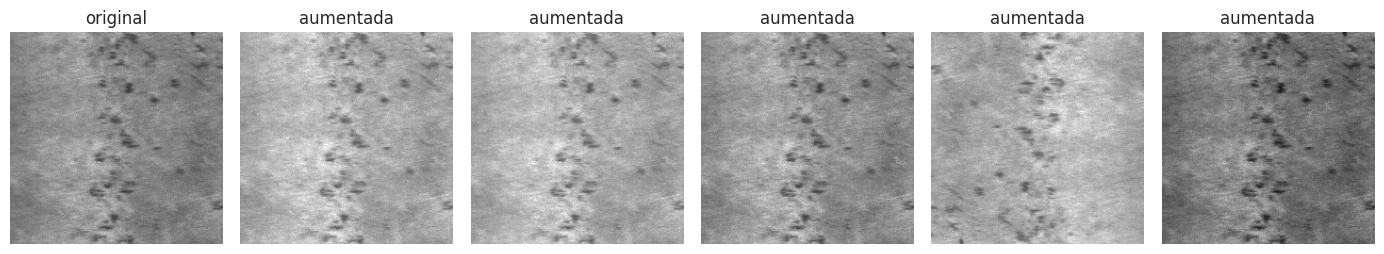

In [6]:
augment = model.get_layer("augmentacion")
sample = images[:1]

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
axes[0].imshow(sample[0, ..., 0], cmap="gray", vmin=0, vmax=255)
axes[0].set_title("original")
for ax in axes[1:]:
    ax.imshow(augment(sample, training=True)[0, ..., 0], cmap="gray", vmin=0, vmax=255)
    ax.set_title("aumentada")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Entrenamiento

- **Optimizador:** Adam con tasa de aprendizaje inicial de 1e-3.
- **ReduceLROnPlateau:** divide la tasa de aprendizaje a la mitad si la pérdida de validación deja de mejorar.
- **EarlyStopping:** detiene el entrenamiento si no mejora en 10 épocas y recupera los mejores pesos.
- **ModelCheckpoint:** guarda el mejor modelo en `models/cnn_baseline.keras`.

In [7]:
EPOCHS = 60
MODEL_PATH = MODEL_DIR / "cnn_baseline.keras"

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5),
    keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True),
]

start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
train_minutes = (time.time() - start) / 60
print(f"Entrenamiento: {train_minutes:.1f} min, {len(history.history['loss'])} épocas")

Epoch 1/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.6484 - loss: 0.9298 - val_accuracy: 0.2407 - val_loss: 3.3275 - learning_rate: 0.0010
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.7760 - loss: 0.5915 - val_accuracy: 0.5278 - val_loss: 1.4625 - learning_rate: 0.0010
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.8209 - loss: 0.5141 - val_accuracy: 0.6157 - val_loss: 1.0119 - learning_rate: 0.0010
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.8749 - loss: 0.3514 - val_accuracy: 0.7731 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8855 - loss: 0.3209 - val_accuracy: 0.6481 - val_loss: 1.0304 - learning_rate: 0.0010
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8790 - loss: 0.3206 - val_accuracy: 0.8009 - val_loss: 0.7489 - learning_rate: 0.0010
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9011 - loss: 0.3186 - val_a

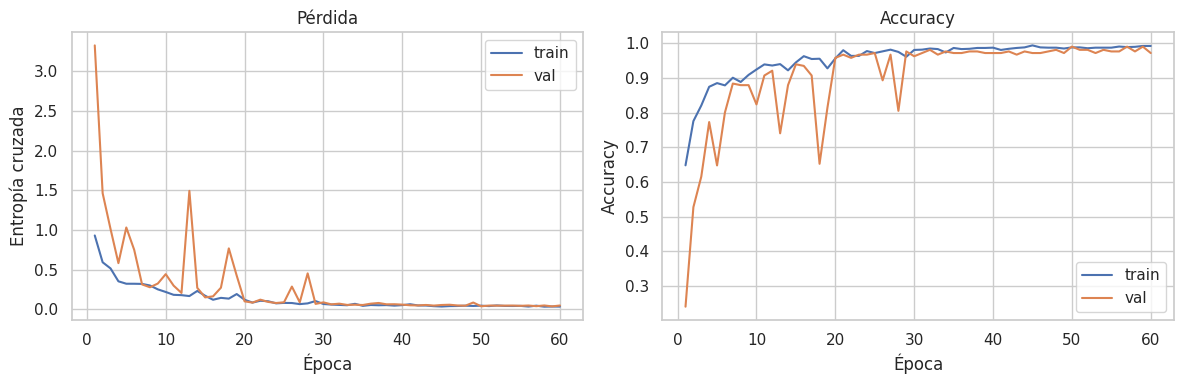

In [8]:
hist = pd.DataFrame(history.history)
hist.index = hist.index + 1
hist.index.name = "epoca"
hist.to_csv(ROOT / "reports" / "02_historial_cnn_baseline.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
hist[["loss", "val_loss"]].plot(ax=axes[0], title="Pérdida")
hist[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Accuracy")
axes[0].set(xlabel="Época", ylabel="Entropía cruzada")
axes[1].set(xlabel="Época", ylabel="Accuracy")
axes[0].legend(["train", "val"])
axes[1].legend(["train", "val"])
plt.tight_layout()
plt.savefig(FIG_DIR / "02_curvas_entrenamiento.png", dpi=150)
plt.show()

## 5. Evaluación en test

Primera y única vez que el modelo ve el conjunto de test. El análisis detallado (matriz de confusión y `classification_report`) se hace en el paso 4, comparando con MobileNetV2.

In [9]:
best = keras.models.load_model(MODEL_PATH)
val_loss, val_acc = best.evaluate(val_ds, verbose=0)
test_loss, test_acc = best.evaluate(test_ds, verbose=0)

metrics = {
    "modelo": "cnn_baseline",
    "parametros": int(best.count_params()),
    "epocas_entrenadas": int(len(hist)),
    "minutos_entrenamiento": round(train_minutes, 1),
    "val_accuracy": round(float(val_acc), 4),
    "test_accuracy": round(float(test_acc), 4),
    "test_loss": round(float(test_loss), 4),
}
(ROOT / "reports" / "metrics_cnn_baseline.json").write_text(json.dumps(metrics, indent=2))
pd.Series(metrics)

,0
modelo,cnn_baseline
parametros,390822
epocas_entrenadas,60
minutos_entrenamiento,2.6
val_accuracy,0.9907
test_accuracy,1.0
test_loss,0.0159


## 6. Guardar resultados

En Colab los archivos generados se pierden al cerrar la sesión. Esta celda descarga un `.zip` con el modelo, las métricas y las figuras. Descomprímelo en la raíz del repositorio local.

In [10]:
if IN_COLAB:
    import shutil
    from google.colab import files

    bundle = Path("/content/resultados_02")
    for rel in ["models/cnn_baseline.keras", "reports/metrics_cnn_baseline.json",
                "reports/02_historial_cnn_baseline.csv", "reports/figures/02_curvas_entrenamiento.png"]:
        (bundle / rel).parent.mkdir(parents=True, exist_ok=True)
        shutil.copy(ROOT / rel, bundle / rel)
    files.download(shutil.make_archive("/content/resultados_02", "zip", bundle))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


**Siguiente paso:** transfer learning con MobileNetV2 (`03_mobilenetv2_transfer.ipynb`).